In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import anndata as ad
import scanpy as sc
import geopandas as gpd
import os
os.chdir("E:/202411_HPV原位测序毕设数据/1_Epi8问题一/20241120/2418792/")
os.getcwd()

'E:\\202411_HPV原位测序毕设数据\\1_Epi8问题一\\20241120\\2418792'

# QC

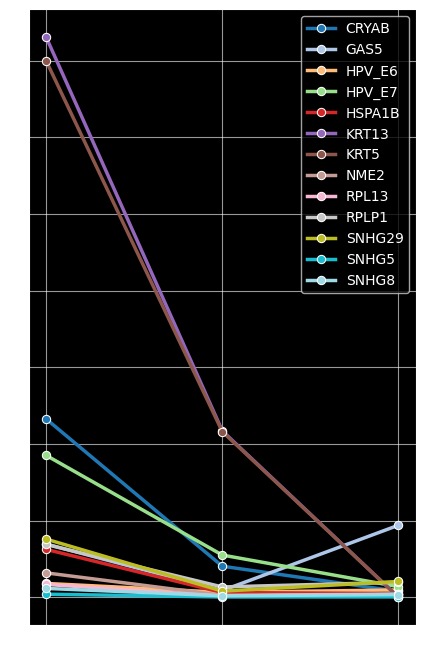

In [6]:
### Plot1: 基因表达趋势图

### 结果读取
mx = pd.read_csv('outs/Matrix.csv', index_col = 0)
centroids = pd.read_csv('outs/CellCentroid.csv', index_col = 2)
gene = pd.read_csv('outs/CellGene.csv')

### 挑取上皮
epi = mx[(mx['KRT5'] > 0) | (mx['KRT13'] > 0)]
centroids = centroids.loc[mx.index, :]
centroids.loc[:,'class'] = 'other'
centroids.loc[epi.index,'class'] = 'epithelium'
centroids['name'] = centroids.index

### 定义epi8
epi8 = epi.loc[:, ['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8']]
epi8_sum = epi8.sum(axis = 1)
thresholds = epi8_sum.quantile(0.6)
epi8_sum = epi8_sum[epi8_sum >= thresholds]
centroids.loc[epi8_sum.index, 'class'] = 'epi8'

### 细胞排序
epi8 = centroids.loc[centroids['class'] == 'epi8','name']
epi8 = mx.loc[epi8, ['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8', 'KRT5', 'KRT13']]
epi8 = epi8.sum(axis = 1)
epi8 = epi8.sort_values(ascending = False)

epi = centroids.loc[centroids['class'] == 'epithelium', 'name']
epi = mx.loc[epi, ['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8', 'KRT5', 'KRT13']]
epi = epi.sum(axis = 1)
epi = epi.sort_values(ascending = False)

other = centroids.loc[centroids['class'] == 'other', 'name']
other = mx.loc[other, ['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8', 'KRT5', 'KRT13']]
other = other.sum(axis = 1)
other = other.sort_values(ascending = False)

# adata = ad.AnnData(
#     X = mx,dtype = np.float32,
#     obs = centroids,
#     obsm ={'spatial': centroids[["column","row"]].copy().to_numpy()})
# sc.pp.normalize_total(adata, inplace=True)
# sc.pp.log1p(adata)
# mx = adata.to_df()

combined_index = epi8.index.tolist() + epi.index.tolist() + other.index.tolist()
mx = mx.loc[combined_index,:]
# mx = (mx - mx.min()) / (mx.max() - mx.min())
mx

result = pd.DataFrame({'Epi8': mx.loc[epi8.index.tolist(),:].mean(),
                       'Epithelium': mx.loc[epi.index.tolist(),:].mean(),
                       'Other': mx.loc[other.index.tolist(),:].mean()})
result = result.T

plt.figure(figsize=(5, 8))
plt.style.use('dark_background')
cmap = plt.cm.tab20
colors = cmap(np.linspace(0, 1, len(result.columns)))
for i, gene in enumerate(result.columns):
    sns.lineplot(data=result[gene], linewidth=2.5, linestyle='-', label=gene, 
                 marker='o', color=colors[i])
plt.grid(True, linestyle='-', alpha=0.6)
plt.xlabel('')
plt.ylabel('')
plt.savefig('Trend_Gene.png', dpi = 300, transparent = False, bbox_inches = 'tight')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13700\361397607.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(transcripts['score'], shade = True, color = '#3399ff', edgecolor = 'white')


10.669503840564667

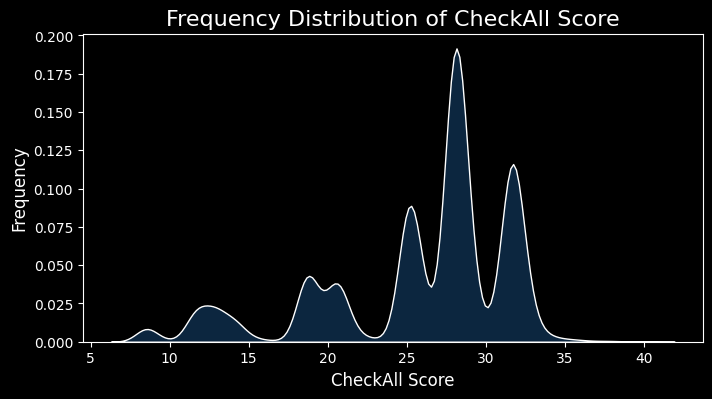

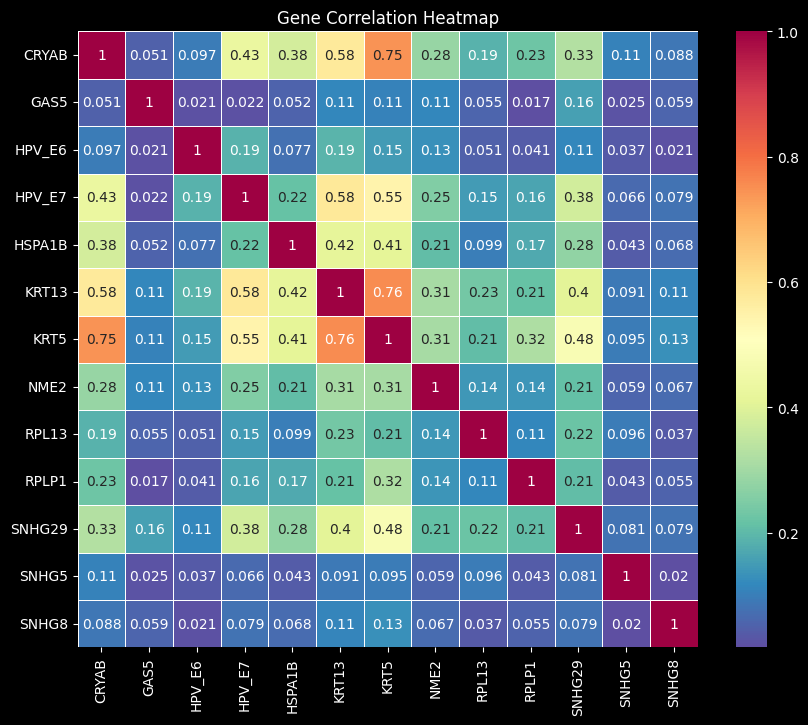

In [7]:
### Plot2: 测序信号质量图

### 数据读取
transcripts = pd.read_csv('outs/transcripts/transcripts.csv', index_col = 0)
plt.style.use('dark_background')
plt.figure(figsize=(8, 4))
# sns.histplot(transcripts['score'], bins=20, kde=True, color='skyblue', edgecolor='black')
sns.kdeplot(transcripts['score'], shade = True, color = '#3399ff', edgecolor = 'white')
plt.title('Frequency Distribution of CheckAll Score', fontsize=16)
plt.xlabel('CheckAll Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.savefig('QC.png', dpi = 300, transparent = False, bbox_inches = 'tight')

### 所有基因的相关性
mx = pd.read_csv('outs/Matrix.csv', index_col = 0)
correlation_matrix = mx.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Spectral_r', linewidths=0.5)
plt.title('Gene Correlation Heatmap')
plt.savefig('Cor_Gene.png', dpi = 300, transparent = False, bbox_inches = 'tight')

### 统计平均信号数
mx.mean().sum()

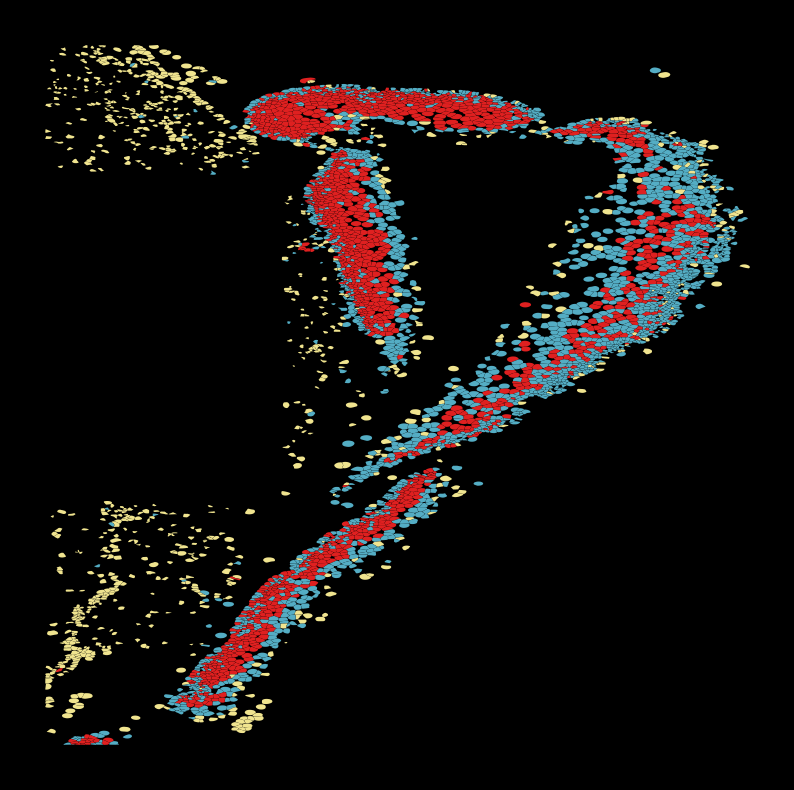

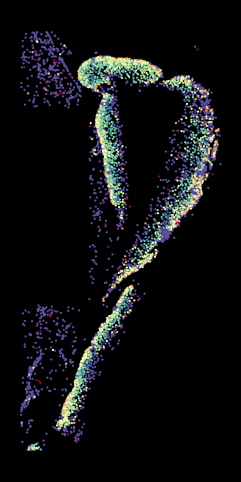

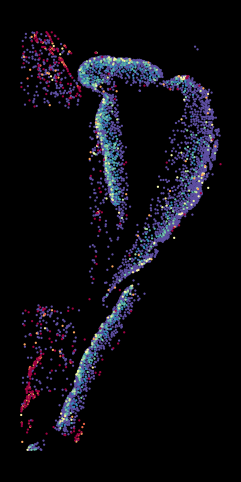

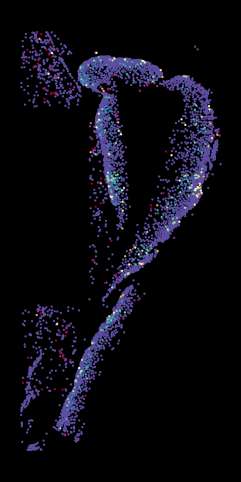

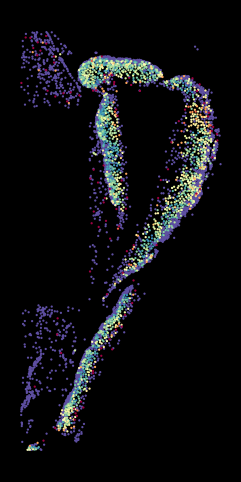

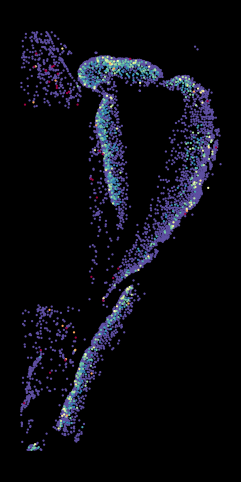

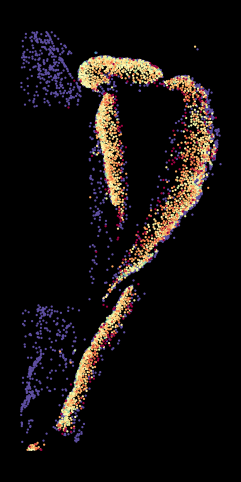

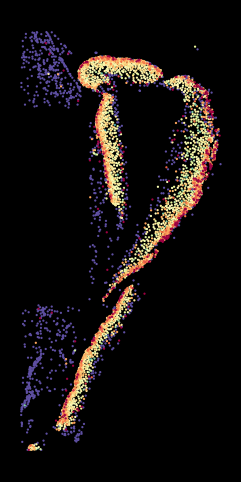

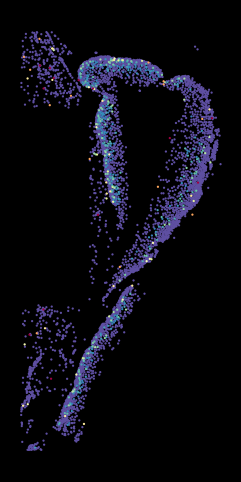

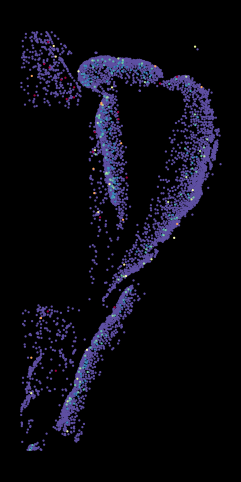

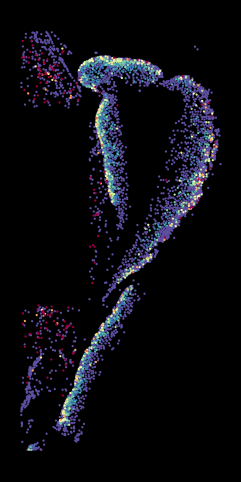

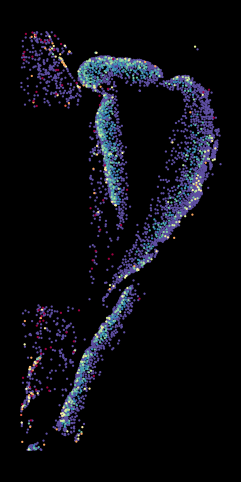

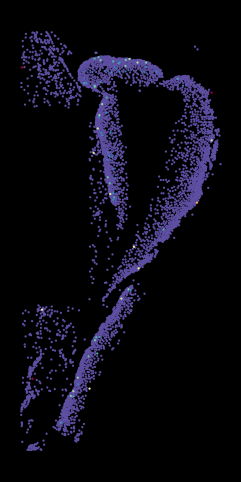

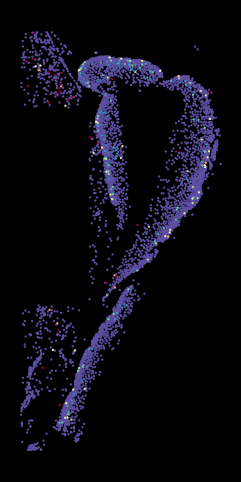

In [8]:
### Plot3: Epi8分布和单基因表达图

### 结果读取
mx = pd.read_csv('outs/Matrix.csv', index_col = 0)
centroids = pd.read_csv('outs/CellCentroid.csv', index_col = 2)
gene = pd.read_csv('outs/CellGene.csv')

### 挑取上皮
epi = mx[(mx['KRT5'] > 0) | (mx['KRT13'] > 0)]
centroids = centroids.loc[mx.index, :]
centroids.loc[:,'class'] = 'other'
centroids.loc[epi.index,'class'] = 'epithelium'
centroids['name'] = centroids.index

### 定义epi8
epi8 = epi.loc[:, ['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8']]
epi8_sum = epi8.sum(axis = 1)
thresholds = epi8_sum.quantile(0.6)
epi8_sum = epi8_sum[epi8_sum >= thresholds]
centroids.loc[epi8_sum.index, 'class'] = 'epi8'

### 砖块图准备
geojson_file = "outs/cells/Cells.geojson"
gdf = gpd.read_file(geojson_file)
gdf = gdf.merge(centroids[['row', 'column', 'class', 'name']], on = ['name'], how = 'left')
gdf.dropna(inplace = True)
class_colors = {'epi8': '#df2020', 'epithelium': '#54adc4', 'other': '#f0e48f'}
gdf['color'] = gdf['class'].map(class_colors).fillna('#808080')

### 砖块图可视化
plt.style.use('dark_background')
figure_size = (10,10)
fig, axes = plt.subplots(1,1,figsize = figure_size)
gdf.plot(ax = axes, color = gdf['color'], aspect=1)
axes.invert_yaxis()
axes.set_aspect('auto')
axes.set_axis_off()
plt.savefig('CellMap.png', dpi = 300, transparent = False, bbox_inches = 'tight')

# ### 单基因可视化
# figure_size = [s * 0.6 for s in figure_size]
# for i in mx.columns.to_list():
#     fig, axes = plt.subplots(figsize = figure_size)
#     plt.style.use('dark_background')
#     gdf.plot(ax = axes, edgecolor = '#666666', linewidth = 0.1, color = '#b3b3b3', alpha = 0.5, aspect=1)
#     sns.scatterplot(data = gene[gene['gene'] == i], x = "x", y = "y", color = 'red', s = 0.5, alpha = 1, ax = axes)
#     axes.set_aspect('auto')
#     plt.gca().invert_yaxis()
#     plt.gca().set_axis_off()
#     plt.savefig(i + '.png', dpi = 300, transparent = False, bbox_inches = 'tight')

### 单基因可视化
adata = ad.AnnData(
    X = mx,dtype = np.float32,
    obs = centroids,
    obsm ={'spatial': centroids[["column","row"]].copy().to_numpy()})
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
figure_size = [s * 0.6 for s in figure_size]
for i in mx.columns.to_list():
    plt.rcParams["figure.figsize"] = figure_size
    sc.pl.spatial(adata, color = i, spot_size = 60, show = False, cmap = 'Spectral_r', title = '', colorbar_loc=None)
    plt.gca().set_axis_off()
    plt.savefig(i + '.png', dpi = 300, transparent = False, bbox_inches = 'tight')

# 其他

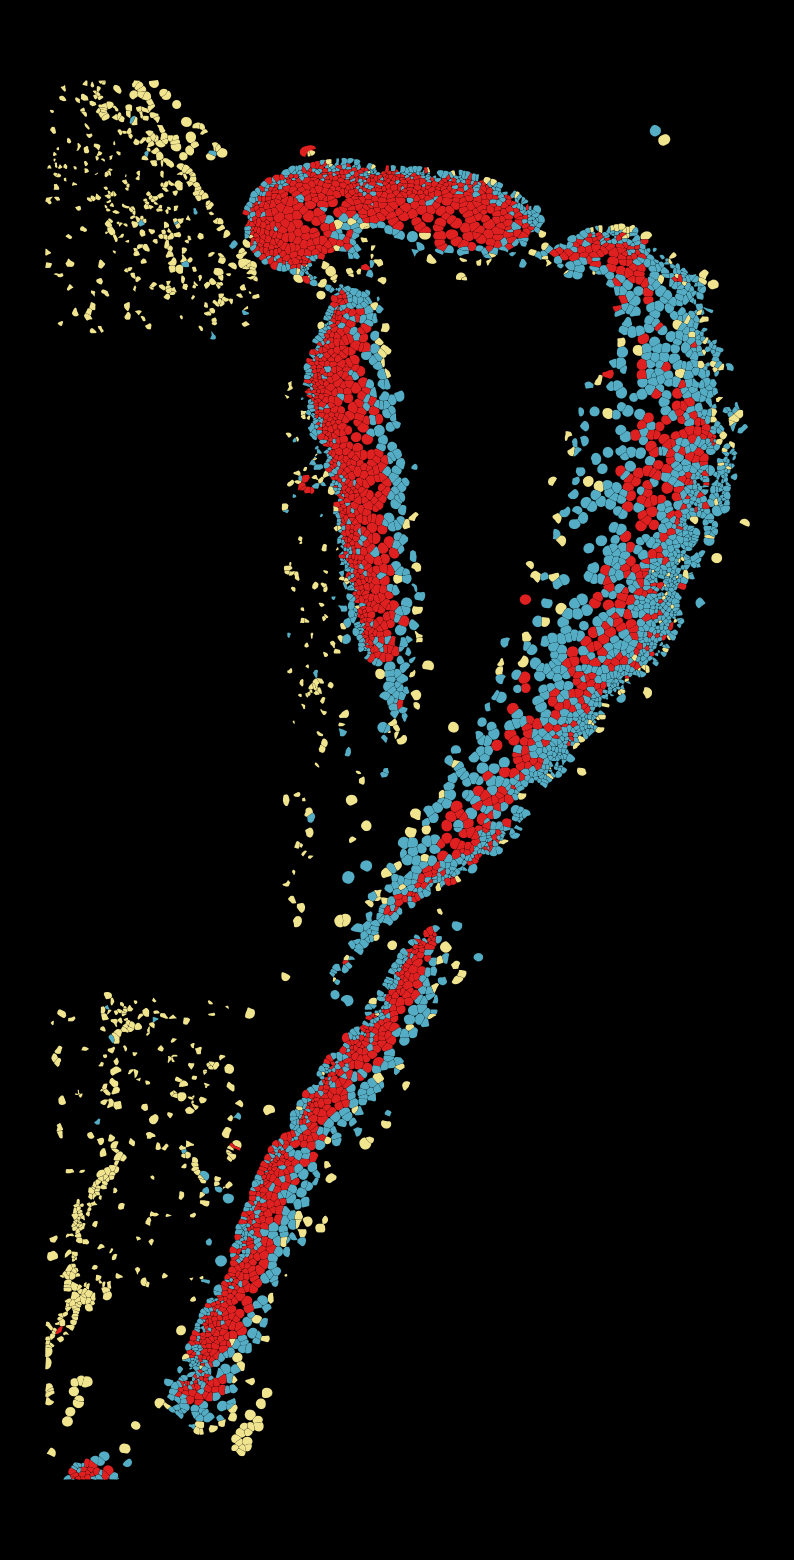

In [9]:
### 调整CellMap大小
### 结果读取
mx = pd.read_csv('outs/Matrix.csv', index_col = 0)
centroids = pd.read_csv('outs/CellCentroid.csv', index_col = 2)
gene = pd.read_csv('outs/CellGene.csv')

### 挑取上皮
epi = mx[(mx['KRT5'] > 0) | (mx['KRT13'] > 0)]
centroids = centroids.loc[mx.index, :]
centroids.loc[:,'class'] = 'other'
centroids.loc[epi.index,'class'] = 'epithelium'
centroids['name'] = centroids.index

### 定义epi8
epi8 = epi.loc[:, ['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8']]
epi8_sum = epi8.sum(axis = 1)
thresholds = epi8_sum.quantile(0.6)
epi8_sum = epi8_sum[epi8_sum >= thresholds]
centroids.loc[epi8_sum.index, 'class'] = 'epi8'

### 砖块图准备
geojson_file = "outs/cells/Cells.geojson"
gdf = gpd.read_file(geojson_file)
gdf = gdf.merge(centroids[['row', 'column', 'class', 'name']], on = ['name'], how = 'left')
gdf.dropna(inplace = True)
class_colors = {'epi8': '#df2020', 'epithelium': '#54adc4', 'other': '#f0e48f'}
gdf['color'] = gdf['class'].map(class_colors).fillna('#808080')

### 砖块图可视化
plt.style.use('dark_background')
figure_size = (10,20)
fig, axes = plt.subplots(1,1,figsize = figure_size)
gdf.plot(ax = axes, color = gdf['color'], aspect=1)
axes.invert_yaxis()
axes.set_aspect('auto')
axes.set_axis_off()
plt.savefig('CellMap.png', dpi = 300, transparent = False, bbox_inches = 'tight')

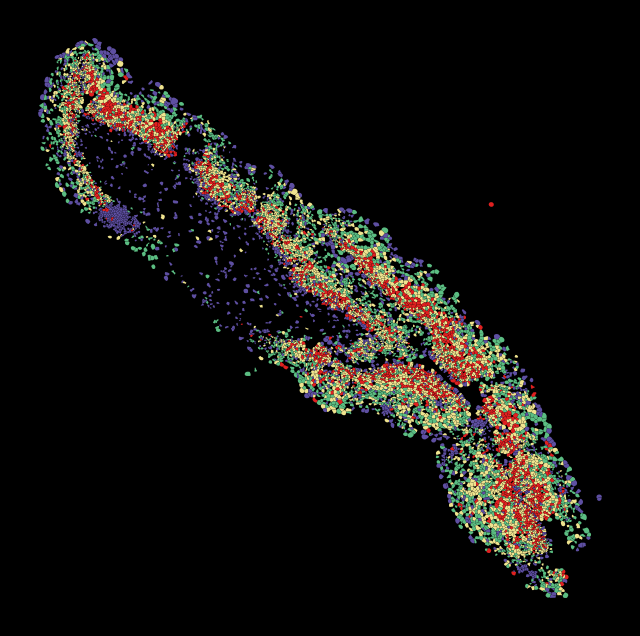

In [66]:
### Epi8用不同分位值进行颜色标注
### 结果读取
mx = pd.read_csv('outs/Matrix.csv', index_col = 0)
centroids = pd.read_csv('outs/CellCentroid.csv', index_col = 2)
gene = pd.read_csv('outs/CellGene.csv')

### 挑取上皮
epi = mx[(mx['KRT5'] > 0) | (mx['KRT13'] > 0)]
centroids = centroids.loc[mx.index, :]
centroids.loc[:,'class'] = 'other'
centroids.loc[epi.index,'class'] = 'epithelium'
centroids['name'] = centroids.index

# 定义epi8和计算总和
epi8 = epi.loc[:, ['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8']]
epi8_sum = epi8.sum(axis=1)
# 计算分位数
quantiles = epi8_sum.quantile([0.33, 0.66])
# 创建分类函数
def assign_quintile(value):
    if value <= quantiles[0.33]:
        return 'Q1'
    elif value <= quantiles[0.66]:
        return 'Q2'
    else:
        return 'Q3'
# 应用分类函数
epi8_sum_quintiles = epi8_sum.apply(assign_quintile)
# 将结果存储到centroids数据框中
centroids.loc[epi8_sum.index, 'class'] = epi8_sum_quintiles

### 砖块图准备
geojson_file = "outs/cells/Cells.geojson"
gdf = gpd.read_file(geojson_file)
gdf = gdf.merge(centroids[['row', 'column', 'class', 'name']], on = ['name'], how = 'left')
gdf.dropna(inplace = True)
# class_colors = {'Q1': '#f0e48f', 'Q2': '#88cfa4', 'Q3': '#ffffbf', 'Q4': '#f88d51', 'Q5': '#9e0142', 
#                 'epithelium': '#f0e48f', 'other': '#5e4fa2'}
class_colors = {'Q1': '#5bbd82', 'Q2': '#f0e48f', 'Q3': '#df2020', 'other': '#5e4fa2'}
gdf['color'] = gdf['class'].map(class_colors).fillna('#808080')

### 砖块图可视化
plt.style.use('dark_background')
figure_size = (8,8)
# figure_size = (10,15)
fig, axes = plt.subplots(1,1,figsize = figure_size)
gdf.plot(ax = axes, color = gdf['color'], aspect=1)
axes.invert_yaxis()
axes.set_aspect('auto')
axes.set_axis_off()
# plt.savefig('CellMap.png', dpi = 300, transparent = False, bbox_inches = 'tight')